In [1]:
%pip install pygad

Note: you may need to restart the kernel to use updated packages.


Initial guess [-1, 1], Result: [0.99999551 0.99999101], Value: 2.0172579078957455e-11, Success: True, Iterations: 31, Time: 0.0047 sec
Initial guess [2, 2], Result: [0.99999565 0.99999129], Value: 1.8932681887175893e-11, Success: True, Iterations: 30, Time: 0.0048 sec
Initial guess [0, 0], Result: [0.99999467 0.99998932], Value: 2.8439990629105454e-11, Success: True, Iterations: 19, Time: 0.0039 sec
PyGAD initial guess [-1, 1], Solution: [1.01054858 1.02050607], Value: 0.00016060302484880988, iterations: 2000, Time: 0.5440 sec
PyGAD initial guess [2, 2], Solution: [0.98619572 0.9736843 ], Value: 0.00031206289296352387, iterations: 2000, Time: 0.5469 sec
PyGAD initial guess [0, 0], Solution: [1.007721   1.01467527], Value: 0.00012789791588633224, iterations: 2000, Time: 0.5814 sec


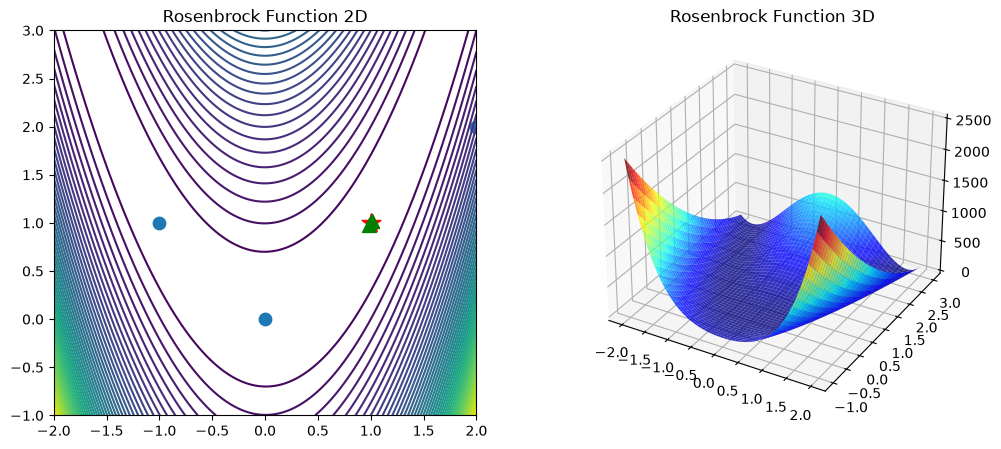

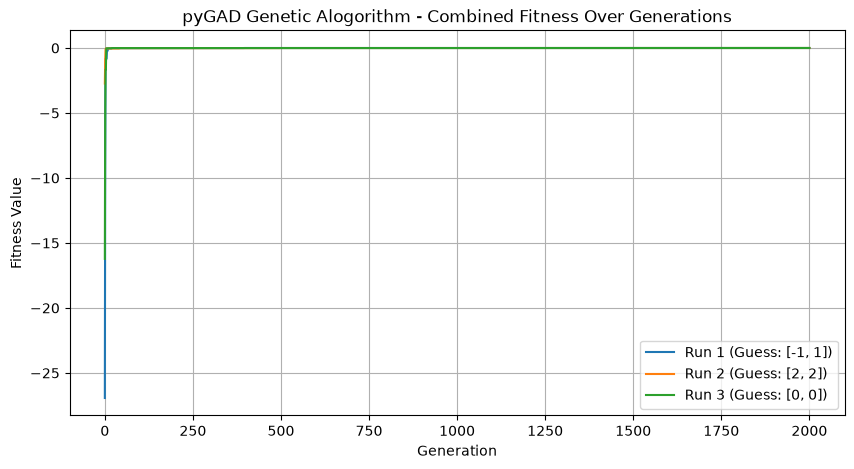

<Figure size 640x480 with 0 Axes>

In [30]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")
elapsed_time = []

# Scipy Optimization
init_guesses = [[-1, 1], [2, 2], [0, 0]]
initial_points = np.array(init_guesses)
ax1.scatter(
    initial_points[:, 0],
    initial_points[:, 1],
    marker='o',
    s=80,
    label='Initial Guess'
)
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")

ax1.scatter(result.x[0], result.x[1], marker='*', s=200, color='red', label='SCIPY Result')
fig_fitness = plt.figure(figsize=(10,5))
# PyGAD Optimization
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution) # pygad maximizes, so negate

elapsed_time = []

for idx, guess in enumerate(init_guesses):
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=2000,
                           sol_per_pop=20,
                           num_genes=2,
                           num_parents_mating=8,
                           fitness_func=fitness_func,
                           init_range_low=-2,
                           init_range_high=2,
                           gene_space={'low':-2, 'high':2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {rosenbrock(solution)}, iterations: {iters}, Time: {elapsed_time:.4f} sec")
    ax1.scatter(solution[0], solution[1], marker='^', s=100, color='green', label='PyGAD Result')
    fitness_history = ga_instance.best_solutions_fitness
    plt.plot(fitness_history, label=f"Run {idx + 1} (Guess: {guess})")

plt.title("pyGAD Genetic Alogorithm - Combined Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness Value")
plt.legend()
plt.grid(True)
plt.show()

ax1.scatter(
    1,
    1,
    marker='X',
    s=150,
    label='Global Minimum (1,1)'
)
ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.show()


1)For three different initial guesses the solution converged to approximately (1,1). Therefore, by changing the initial the solution didn't change.
From the 2D contour, the Rosenbrock function is like avalley giving global minimum at (1,1). Therefore it is a global minimum not a local minimum.
minimum value is approximately 10^-11, i.e., almost zero.

2)By using pyGAD we are getting near value of global minimum but it is not as accurate as SciPy(BFGS method)

3)On comparing, the BFGS method better for this Rosenbrock optimization problem.

Initial guess [0, 0], Result: [ 9.99999966e-01 -1.64047755e-08], Value: 5.950412924404877e-15, Success: True, Iterations: 3, Time taken: 0.0008 seconds
Initial guess [-4, 4], Result: [1.00000002e+00 5.98350409e-08], Value: 5.2197810463598925e-15, Success: True, Iterations: 18, Time taken: 0.0030 seconds
Initial guess [4, 0], Result: [1.00000001e+00 3.95264636e-07], Value: 1.566975197383418e-13, Success: True, Iterations: 10, Time taken: 0.0012 seconds
PyGAD initial guess [0, 0], Solution: [ 9.99705587e-01 -9.17628865e-04], Value: 1.2743449573634728e-06, Iterations: 3000, Time taken: 1.2374 seconds
PyGAD initial guess [-4, 4], Solution: [ 9.99095469e-01 -8.14401485e-04], Value: 4.748774193964794e-06, Iterations: 3000, Time taken: 1.2578 seconds
PyGAD initial guess [4, 0], Solution: [ 9.99542980e-01 -4.98738774e-04], Value: 1.2922397002661531e-06, Iterations: 3000, Time taken: 1.2331 seconds


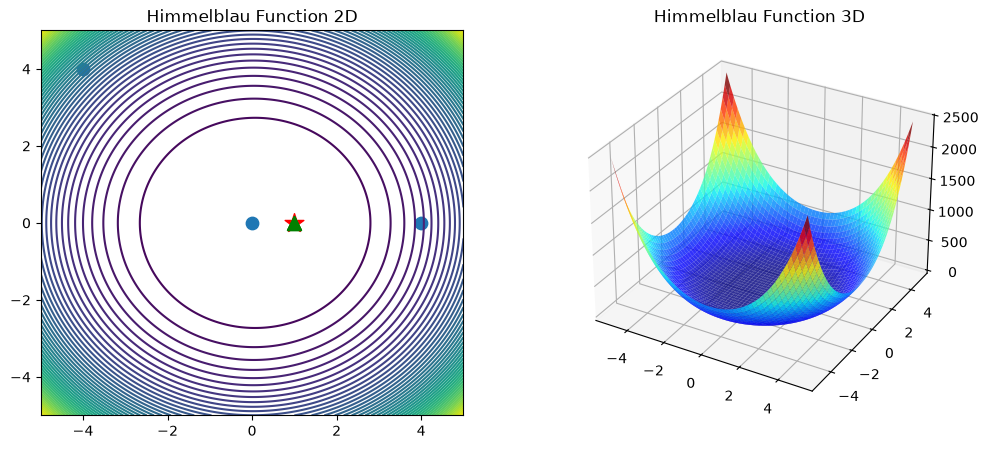

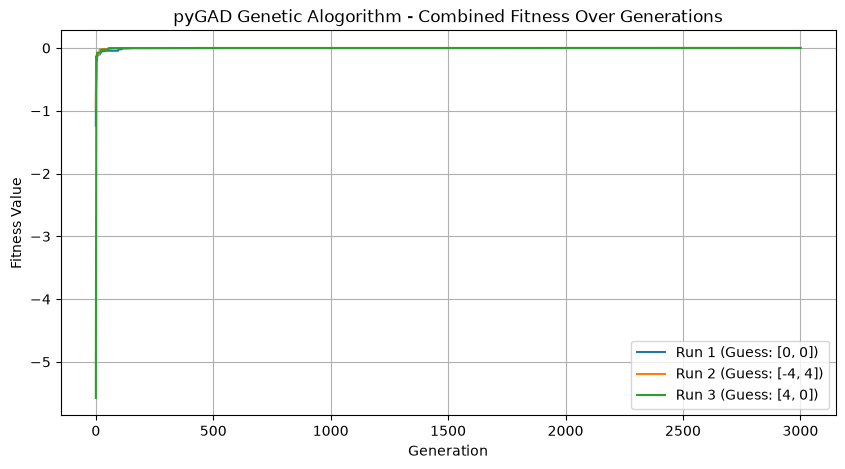

<Figure size 640x480 with 0 Axes>

In [31]:
def himmelblau(x):
    x = np.asarray(x) # Convert to numpy array
    return (x[0]**2 + x[1]**2 - 1)**2 + (x[0] - 1)**2 + (x[1])**2
    #return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")

elapsed_time = []
# Scipy Optimization
init_guesses = [[0, 0], [-4, 4], [4, 0]]
initial_points = np.array(init_guesses)
ax1.scatter(
    initial_points[:, 0],
    initial_points[:, 1],
    marker='o',
    s=80,
    label='Initial Guess'
)
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()   # end timer
    elapsed_time.append(end_time - start_time)
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time taken: {elapsed_time[-1]:.4f} seconds")

ax1.scatter(result.x[0], result.x[1], marker='*', s=200, color='red', label='SCIPY Result')
# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)
elapsed_time = []
plt.figure(figsize=(10,5))
for idx,guess in enumerate(init_guesses):
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=3000,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()   # end timer
    elapsed_time.append(end_time - start_time)
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}, Iterations: {iters}, Time taken: {elapsed_time[-1]:.4f} seconds")
    ax1.scatter(solution[0], solution[1], marker='^', s=100, color='green', label='PyGAD Result')
    fitness_history = ga_instance.best_solutions_fitness
    plt.plot(fitness_history, label=f"Run {len(elapsed_time)} (Guess: {guess})")

plt.title("pyGAD Genetic Alogorithm - Combined Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness Value")
plt.legend()
plt.grid(True)
plt.show()

ax1.scatter(
    1,
    0,
    marker='X',
    s=150,
    color='black',
    label='Global Minimum (1,0)'
)

ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.show()

For three different initial guesses the solution converged to approximately (1,0). Therefore, by changing the initial the solution didn't change.
From the 2D contour, the Rosenbrock function is like avalley giving global minimum at (1,0). Therefore it is a global minimum not a local minimum.
minimum value is approximately 10^-15, i.e., almost zero.

By using pyGAD we are getting near value of global minimum but it is not as accurate as SciPy(BFGS method)

On comparing, the BFGS method better for this optimization problem.